#3D GAN PROJECT

Generative Adversarial Networks (GANs) have revolutionized the field of deep learning by enabling the generation of highly realistic synthetic data, from images to audio and beyond. 3D GANs extend 2D GANs capabilites to three-dimensional data, making them invaluable for applications such as 3D object generation, medical imaging, video game assets, and virtual reality.     In this notebook, we will explore 2 different 3D GANs architecture where we will try to generate 3D objects from the dataset ModelNet 10.

##Dataset

1. Firstly we import all the libraries we will need

In [ ]:
import torch
import numpy as np
import os
from torch.utils.data import random_split, Dataset, DataLoader
import scipy.io
import h5py
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision.transforms import ToTensor,Compose
from torchvision.utils import make_grid
import time as time
from tqdm import tqdm
from IPython import display

2. We now create the voxelgrid, used to represent 3D geometric shapes as a probability distribution of binary variables on a 3D Voxel grid. This class is responsible for:
*   Reading a text file that contains paths to .h5 (HDF5) files.
*   Load voxel data, labels (labels) and poses from each HDF5 file.
*   Combine data from multiple files into a single array.
*   Provide a method of accessing the elements of the dataset, which can be used with a DataLoader








In [ ]:
class MyVoxelDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels=None):
        # Read the text file containing the paths to the .h5 files
        with open(data) as file:
            lines = file.readlines()

        # Define base directory
        base_dir = "/content/drive/MyDrive/datasets/"

        # Delete newline characters and create a paths list
        self.paths = [os.path.join(base_dir, line.strip('\n').replace('../../datasets', '').lstrip('/')) for line in lines]

        # Combine all .h5 files into their respective arrays of data, labels, and poses
        self.data, self.label, self.label_pose = self._combine_files()

        # Verify that self.data was loaded correctly
        print(f"Number of samples loaded into self.data: {len(self.data)}")  # Debug

    def _combine_files(self):
        combined_data = []
        combined_label = []
        combined_label_pose = []

        # Itera sui percorsi ai file .h5
        for path in self.paths:
            print(f"Opening file: {path}")
            try:
                with h5py.File(path, 'r') as file:
                    # Extract voxel,labels and poses
                    data = file['data'][:]

                    label = np.int64(file['label'][:])

                    label_pose = np.int64(file['label_pose'][:])


                    # Add extracted data to combined lists
                    combined_data.append(data)
                    combined_label.append(label)
                    combined_label_pose.append(label_pose)
                    print(f"File {path} loaded succesfully.")
            except Exception as e:
                print(f"Error while opening file {path}: {e}")

        # Concatenate only if data is present
        combined_data = np.concatenate(combined_data, axis=0) if combined_data else np.array([])
        combined_label = np.concatenate(combined_label, axis=0) if combined_label else np.array([])
        combined_label_pose = np.concatenate(combined_label_pose, axis=0) if combined_label_pose else np.array([])

        return combined_data, combined_label, combined_label_pose

    def __len__(self):
        # Return number of datapoints in the dataset
        return len(self.data)

    def __getitem__(self, idx):
        # Return a single datapoint
        data = self.data[idx]
        label = self.label[idx]
        label_pose = self.label_pose[idx]
        return data, label, label_pose

3. We now write a transformation function during dataset initialization:
*   CropTransform: This class is used to crop the voxel data. It takes a central portion of the voxel grid from a size of 36x36x36 to a size of 32x32x32, removing 2 voxels along each axis. This reduces the size of the data evenly.
*   ToTensor: Converts voxel data to a PyTorch tensor (necessary because PyTorch works with tensors, not NumPy arrays). Also, the data is converted to float32.
*   Compose: This function of the  *torchvision.transforms* library allows multiple transformations to be applied sequentially, in this case clipping (CropTransform) and conversion to tensor (ToTensor).

<br>The transformations will be automatically applied each time a batch of data is loaded from the DataLoader.










In [ ]:
from torchvision.transforms import Compose

class CropTransform(torch.nn.Module):
    def forward(self, data):
        # Remove 2 voxel along each axis
        cropped_data = data[:, 2:34, 2:34, 2:34]  # Assume first dimension is channel size
        return cropped_data

class ToTensor(torch.nn.Module):
    def forward(self, data):
        # Tensor conversion
        tensor = torch.from_numpy(data.astype(np.float32))
        return tensor

# Create transformations pipeline
transforms = Compose([
    CropTransform(),
    ToTensor()
])

4. Now we fetch the dataset uploaded to Google Drive and we create the dataloaders

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
device = "cuda" if torch.cuda.is_available() else "cpu" #Define device

Mounted at /content/drive


In [ ]:
train_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10_24/hdf5/train/train.txt',transforms)
test_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10_24/hdf5/test/test.txt', transforms)

# Dataloaders with batches of 32
train_dataloader = DataLoader(train_dataset,32, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_dataset,32, shuffle=False, num_workers=0)

Opening file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5 loaded succesfully.
Opening file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5.0002
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5.0002 loaded succesfully.
Opening file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5.0003
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5.0003 loaded succesfully.
Opening file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5.0004
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat//poseplan_MN10_24/hdf5/train/train.hdf5.0004 loaded succesfully.
Opening file: /content/drive/MyDrive/datasets/

And combine the data into an entire deataset

In [ ]:
combined_dataset = torch.utils.data.ConcatDataset([train_dataset, test_dataset])
combined_dataloader = DataLoader(combined_dataset, 32, shuffle=True, num_workers=0)

print(f"Number of samples in combined dataset: {len(combined_dataset)}")


Number of samples in combined dataset: 58788


##Narrowing the dataset

Given the simple nature of this architecture I figured that the best way for it to capture the probability distribution from the latent space was to focus on a single class of objects (chairs in this case). The types of chairs in the MN10 dataset are very different from each other ranging from office to kitchen to design chairs so my wish is for the network to be able to capture the most important features. Not only I fed a single class in to the network but I also made it so that all the chairs would be rotated along the same direction.

In [ ]:
TGT_LABEL = 2 #Chair label
TGT_POSE = 42 #Random rotation label picked among 12 different orientations labels

def create_chair_dataset(original_dataset):
    chair_data = []
    chair_labels = []
    chair_label_poses = []

    # Iterate through the original dataset
    for i in range(len(original_dataset)):
        data, label, label_pose = original_dataset[i]

        if label == TGT_LABEL and label_pose==TGT_POSE:
            chair_data.append(data)
            chair_labels.append(label)
            chair_label_poses.append(label_pose)

    # Convert lists to numpy arrays
    chair_data = np.array(chair_data)
    chair_labels = np.array(chair_labels)
    chair_label_poses = np.array(chair_label_poses)

    # Create a simplified class for the filtered dataset
    class FilteredVoxelDataset(torch.utils.data.Dataset):
        def __init__(self, data, labels, label_poses, transforms=None):
            self.data = data
            self.labels = labels
            self.label_poses = label_poses
            self.transforms = transforms

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            data = self.data[idx]
            label = self.labels[idx]
            label_pose = self.label_poses[idx]

            if self.transforms:
                data = self.transforms(data)

            return data, label, label_pose

    chair_dataset = FilteredVoxelDataset(chair_data, chair_labels, chair_label_poses, transforms=transforms)

    return chair_dataset

chair_train_dataset = create_chair_dataset(combined_dataset)

chair_train_dataloader = DataLoader(chair_train_dataset, 32, shuffle=True, num_workers=0)

print(f"Number of samples in the chair training dataset: {len(chair_train_dataset)}")


Number of samples in the chair training dataset: 989


Let's see a single random point from the dataset

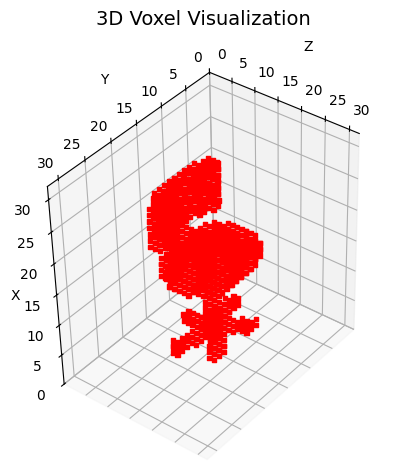

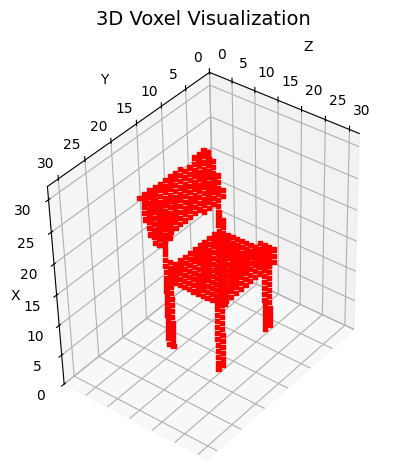

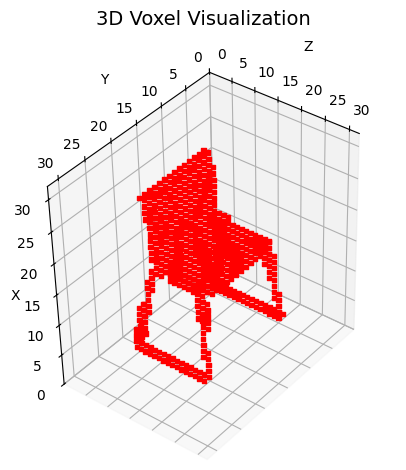

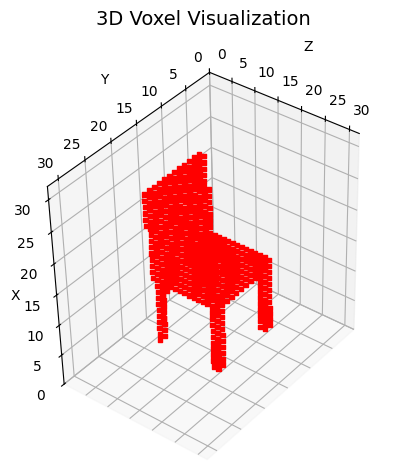

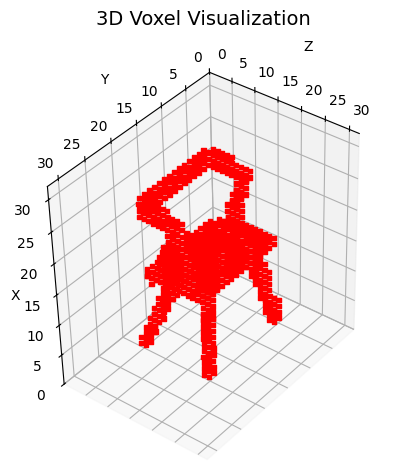

In [ ]:
def plot_voxelgrid(voxel_data):

    if isinstance(voxel_data, torch.Tensor):
        voxel_data = voxel_data.squeeze().numpy()
    elif isinstance(voxel_data, np.ndarray) and voxel_data.ndim == 4 and voxel_data.shape[0] == 1:
         voxel_data = voxel_data.squeeze()


    if voxel_data.ndim != 3:
        print(f"Expected 3D voxel data, but got {voxel_data.ndim} dimensions.")
        return

    # Create a 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Get the coordinates of the occupied voxels
    x, y, z = np.where(voxel_data > 0)

    # Plot the filled voxels as points using scatter
    ax.scatter(x, y, z, c='red', marker='s', s=10, alpha=1)
    ax.view_init(elev=30, azim=45,roll=245)


    ax.set_xlabel('X',labelpad=-2)
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Voxel Visualization', fontsize=14, pad=35)

    # Set equal scaling for all axes
    max_range = np.array([voxel_data.shape[0], voxel_data.shape[1], voxel_data.shape[2]]).max()
    ax.set_xlim(0, max_range)
    ax.set_ylim(0, max_range)
    ax.set_zlim(0, max_range)

    plt.tight_layout()
    plt.show()

if chair_train_dataset and len(chair_train_dataset) > 0:
    try:
      for i in range(5):
        sample = np.random.randint(0,len(chair_train_dataset))
        first_sample_data, _, _ = chair_train_dataset[sample]
        plot_voxelgrid(first_sample_data)
    except IndexError:
        print("filtered_train_dataset is empty.")

##Simple DCGAN

We now try to build a GAN architecture that relies on a simple architecture where our generator and discriminator are both made of 4 3D convolutional layers with Leaky ReLU activation functions. More specifically the generator employs the function ConvTranspose3D to enable upsampling, Batchnorm to stabilize training and sigmoid such that values are normalized for voxel probabilities, while the discriminator unlike the generator, often omit batch norm to avoid artifacts (common in GANs). Dropout is also emplyoed in order to improve robustness y preventing overconfidence in fake/real decisions.

###Generator

This generator transforms a low-dimensional input noise vector (input_size) into a 3D voxel grid (likely representing a 3D object). It consists of two main parts:

Fully Connected (FC) Network (fc_net):
*   Expands the input noise into a high-dimensional tensor (4×4×4×256).
*   Uses BatchNorm1d and LeakyReLU for stable training.

3D Transposed Convolutional Network (conv_model):
*  Gradually upsamples the tensor through four 3D transposed convolutions (stride=2), doubling spatial dimensions each time (e.g., 4×4×4 → 32×32×32).
*   Each layer includes BatchNorm3d and LeakyReLU (slope=0.2) except the final layer.
*   Ends with a 3D convolution (no stride) and Sigmoid to produce a 1-channel voxel grid with values in [0, 1].

In [ ]:
class Generator(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.input_size = input_size

        self.fc_net = nn.Sequential(
            nn.Linear(input_size, 4*4*4*256, bias=False),
            nn.BatchNorm1d(4*4*4*256),
            nn.LeakyReLU(0.2)
        )

        self.conv_model = nn.Sequential(
            nn.ConvTranspose3d(256, 128, 4, 2, 1 ,bias=False),
            nn.BatchNorm3d((128)),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose3d(128, 64, 4, 2, 1 ,bias=False),
            nn.BatchNorm3d((64)),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose3d(64, 32,  4, 2, 1),
            nn.BatchNorm3d((32)),
            nn.LeakyReLU(0.2),
            nn.Conv3d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.fc_net(x)
        y = y.reshape((-1, 256, 4, 4, 4))
        y = self.conv_model(y)
        return y

Weight initialization can be either done via normal or Xavier initialization by adding and removing comment hashtags

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        #nn.init.xavier_uniform_(m.weight.data)
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        #nn.init.xavier_uniform_(m.weight.data)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.2)
        nn.init.constant_(m.bias.data, 0)

Produce a noise vector of size `[1, 200]` and use the (as yet **untrained**) generator to create an image.

In [ ]:
BATCH_SIZE = 32
LATENT_SPACE_DIMENSION = 200
generator = Generator(LATENT_SPACE_DIMENSION)
generator.apply(weights_init)

Generator(
  (fc_net): Sequential(
    (0): Linear(in_features=200, out_features=16384, bias=False)
    (1): BatchNorm1d(16384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (conv_model): Sequential(
    (0): ConvTranspose3d(256, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose3d(128, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): ConvTranspose3d(64, 32, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (7): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv3d(32, 1, kernel_size=(3, 3, 3), 

In [ ]:
noise = torch.normal(0, 1, [BATCH_SIZE, LATENT_SPACE_DIMENSION])
print(noise.shape)
generated_image = generator(noise).detach()
print(generated_image.shape)


torch.Size([32, 200])
torch.Size([32, 1, 32, 32, 32])


###Discriminator

3D Convolutional Layers:
1.   Layer 1: Conv3d(1, 64, 4, stride=2, padding=1)
<br>Input: 1-channel voxel grid (e.g., [batch, 1, 32, 32, 32]).
<br>Downsamples to 16×16×16 using stride-2 convolutions.
2.   Layer 2: Conv3d(64, 128, 4, stride=2, padding=1)
<br>Further downsamples to 8×8×8.
3. Layer 3: Conv3d(128, 256, 4, stride=2, padding=1)
<br>Final downsampling to 4×4×4.

Activation & Regularization:
*   LeakyReLU (slope=0.2): Introduces non-linearity while avoiding dead gradients
*  Dropout (p=0.3): Reduces overfitting by randomly zeroing 30% of activations during training.

Classification Head:
*   Flatten(): Converts the 4×4×4×256 feature map into a 1D vector (256x4x4x*4 = 16,384 units).
*   Linear(16,384 → 1): Produces a single scalar (logit) representing "real" (high) or "fake" (low).







In [ ]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(
            nn.Conv3d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(256*4*4*4, 1),
        )


    def forward(self, x):
        y = self.model(x)
        return y

Apply weights as before and use the untrained discriminator to classify the generated images as real or fake. The model will be trained to output the probability that the image is real.

In [ ]:
discriminator = Discriminator()
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv3d(1, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Conv3d(128, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=16384, out_features=1, bias=True)
  )
)

### Define the loss and optimizers

The overall network is trained with a **minimax loss function**:

$ \min_{G} \max_{D} {V(D,G)}=\mathbb{E}_x[log(D(x))] + \mathbb{E}_z[log(1-D(G(z)))]$


This approach derives from game theory where we have a two players **minimax game** with value function $V(D, G)$, where:
* the *Generator* tries to *maximize* the overall loss function,
* the *Discriminator* tries to *minimize* the overall loss function.

#### Discriminator loss

This method evaluates the discriminator’s performance by measuring its ability to distinguish between generated and real voxels.


In [ ]:
cross_entropy = nn.BCEWithLogitsLoss()
def discriminator_loss(real_output, fake_output, device):
    real_loss = cross_entropy(real_output, torch.ones_like(real_output, device=device))
    fake_loss = cross_entropy(fake_output, torch.zeros_like(fake_output, device=device))
    total_loss = real_loss + fake_loss
    return total_loss

####Generator loss
The generator’s loss measures its ability to fool the discriminator. The loss is given by the following formula

$\frac{1}{m}\sum_{i=1}^{m}-\log(D(G(\boldsymbol{z}^{(i)})))$

This revised loss represents the binary cross-entropy between the discriminator’s predictions on fake samples $D(G(\boldsymbol{z}^{(i)}))$ and a target probability distribution where all labels are 1: $y^{(i)} = 1 \forall i$. It forces the generator to produce samples that maximize the discriminator’s confidence in classifying them as real.

In [ ]:
def generator_loss(fake_output, device):
    gen_loss = cross_entropy(fake_output, torch.ones_like(fake_output, device=device))
    return gen_loss

####Optimizers
The optimizers parameters have been defined via trail and error process, setting parameters in a way that neither of the 2 components would overpower the other. In particular a special attention was needed for the discriminator optimizer since it occured more than once that it would become much stronger than the generator forcing the latter into a corner making it output empty samples after 20/30 epochs.

In [ ]:
gen_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
dis_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

### Define the training loop and train

We set some parameters including the number of epochs and the dimension of the latent space. 200 seemed a good solution to give enough expressiveness without overcomplicating training.

In [ ]:
EPOCHS = 100
noise_dim = 200
num_examples_to_generate = 3
seed = torch.randn([num_examples_to_generate, noise_dim])

We now define the train, train_step and image_display function that we will need to train and to observe how the training of the GAN is going

####Training step

In [ ]:
def train_step(images, generator, discriminator, BATCH_SIZE, noise_dim, device, dis_opt, gen_opt):
    noise = torch.randn([BATCH_SIZE, noise_dim], device=device)
    generated_images = generator(noise).float()

    # Check for NaNs or Infs in generated images
    if torch.isnan(generated_images).any() or torch.isinf(generated_images).any():
        print("NaN or Inf detected in generated_images!")
        return torch.tensor(0.0), torch.tensor(0.0) # Skip training step

    # Convert images to float32
    real_output = discriminator(images.float())
    fake_output = discriminator(generated_images.detach())

    # Check for NaNs or Infs in discriminator outputs
    if torch.isnan(real_output).any() or torch.isinf(real_output).any():
        print("NaN or Inf detected in real_output!")
        return torch.tensor(0.0), torch.tensor(0.0) # Skip training
    if torch.isnan(fake_output).any() or torch.isinf(fake_output).any():
        print("NaN or Inf detected in fake_output!")
        return torch.tensor(0.0), torch.tensor(0.0) # Skip training

    disc_loss = discriminator_loss(real_output, fake_output, device)
    dis_opt.zero_grad()
    disc_loss.backward()
    dis_opt.step()

    fake_output = discriminator(generated_images)

    # Check for NaNs or Infs in discriminator output after generator step
    if torch.isnan(fake_output).any() or torch.isinf(fake_output).any():
        print("NaN or Inf detected in fake_output after generator step!")
        return torch.tensor(0.0), disc_loss.detach().cpu() # Skip generator step

    gen_loss = generator_loss(fake_output, device)
    gen_opt.zero_grad()
    gen_loss.backward()
    gen_opt.step()
    return gen_loss.detach().cpu(), disc_loss.detach().cpu()

####Image generation

In [ ]:
def generate_and_save_images(model, epoch, test_input):
    model.eval()
    with torch.no_grad():
        predictions = model(test_input).detach().cpu()

    # Visualize the generated 3D voxels
    fig = plt.figure(figsize=(15, 10))

    # Display a few generated examples
    num_examples_to_display = 2

    for i in range(num_examples_to_display):
        ax = fig.add_subplot(2, num_examples_to_display // 2, i + 1, projection='3d')

        # Get a single generated voxel grid
        generated_voxel_grid = predictions[i, 0].numpy()

        thresholded_voxel_grid = (generated_voxel_grid > 0.5)

        ax.voxels(thresholded_voxel_grid, facecolor='red', edgecolor='k')

        ax.set_title(f"Generated {i+1}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=30, azim=45, roll=240)

    plt.suptitle(f"Generated 3D Voxels at Epoch {epoch:04d}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('generated_voxels_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

    model.train()


####Main train loop

In [ ]:
def train(dataloader, epochs, generator, discriminator, BATCH_SIZE, noise_dim, device, dis_opt, gen_opt):
  gloss = []
  dloss = []
  iterator = tqdm(dataloader)
  for epoch in tqdm(range(epochs), desc="GAN Training"):

    start = time.time()
    print(f"Epoch {epoch+1}/{epochs}")
    gen_losses = []
    disc_losses = []
    iterator_2 = tqdm(dataloader, desc=f"Epoch {epoch}",position=0, leave=False)
    for image_batch, _ ,_ in iterator_2:
        image_batch = image_batch.to(device)
        gen_loss, disc_loss = train_step(image_batch, generator, discriminator, BATCH_SIZE, noise_dim, device, dis_opt, gen_opt)
        gen_losses.append(gen_loss.detach().cpu())
        disc_losses.append(disc_loss.detach().cpu())
    print(f"Epoch {epoch}: G_loss={np.mean(gen_losses):.3f}, D_loss={np.mean(disc_losses):.3f}")

    gloss.append(np.mean(gen_losses))
    dloss.append(np.mean(disc_losses))
    #Produce images
    display.clear_output(wait=True)
    generate_and_save_images(generator,epoch + 1,seed.to(device))

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))
    plt.figure(figsize=(10, 5))
    plt.plot(gloss, label='Generator Loss')
    plt.plot(dloss, label='Discriminator Loss')
    plt.title('Generator and Discriminator Loss during Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"Generator loss: {gloss[-1]}")
    print(f"Discriminator loss: {dloss[-1]}")

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,epochs,seed.to(device))

  return gloss, dloss

We can now begin training our GAN

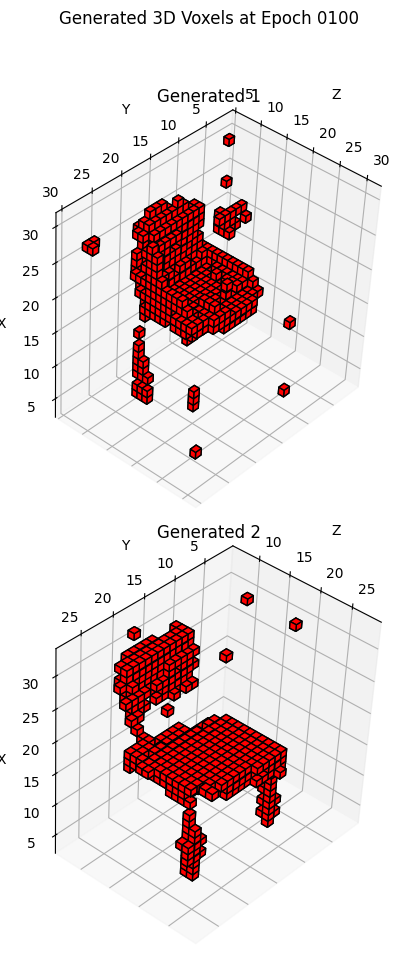

  0%|          | 0/31 [14:44<?, ?it/s]


In [ ]:
generator.to(device)
discriminator.to(device)
gloss, dloss = train(chair_train_dataloader, EPOCHS, generator, discriminator, 32, noise_dim, device, dis_opt, gen_opt)

We now a few results after 1,21 and 87 epochs. Note how from noise we go gradually to voxels that clearly present elements of a chair such as legs,seat and back (albeit with still a lot of refining to do).

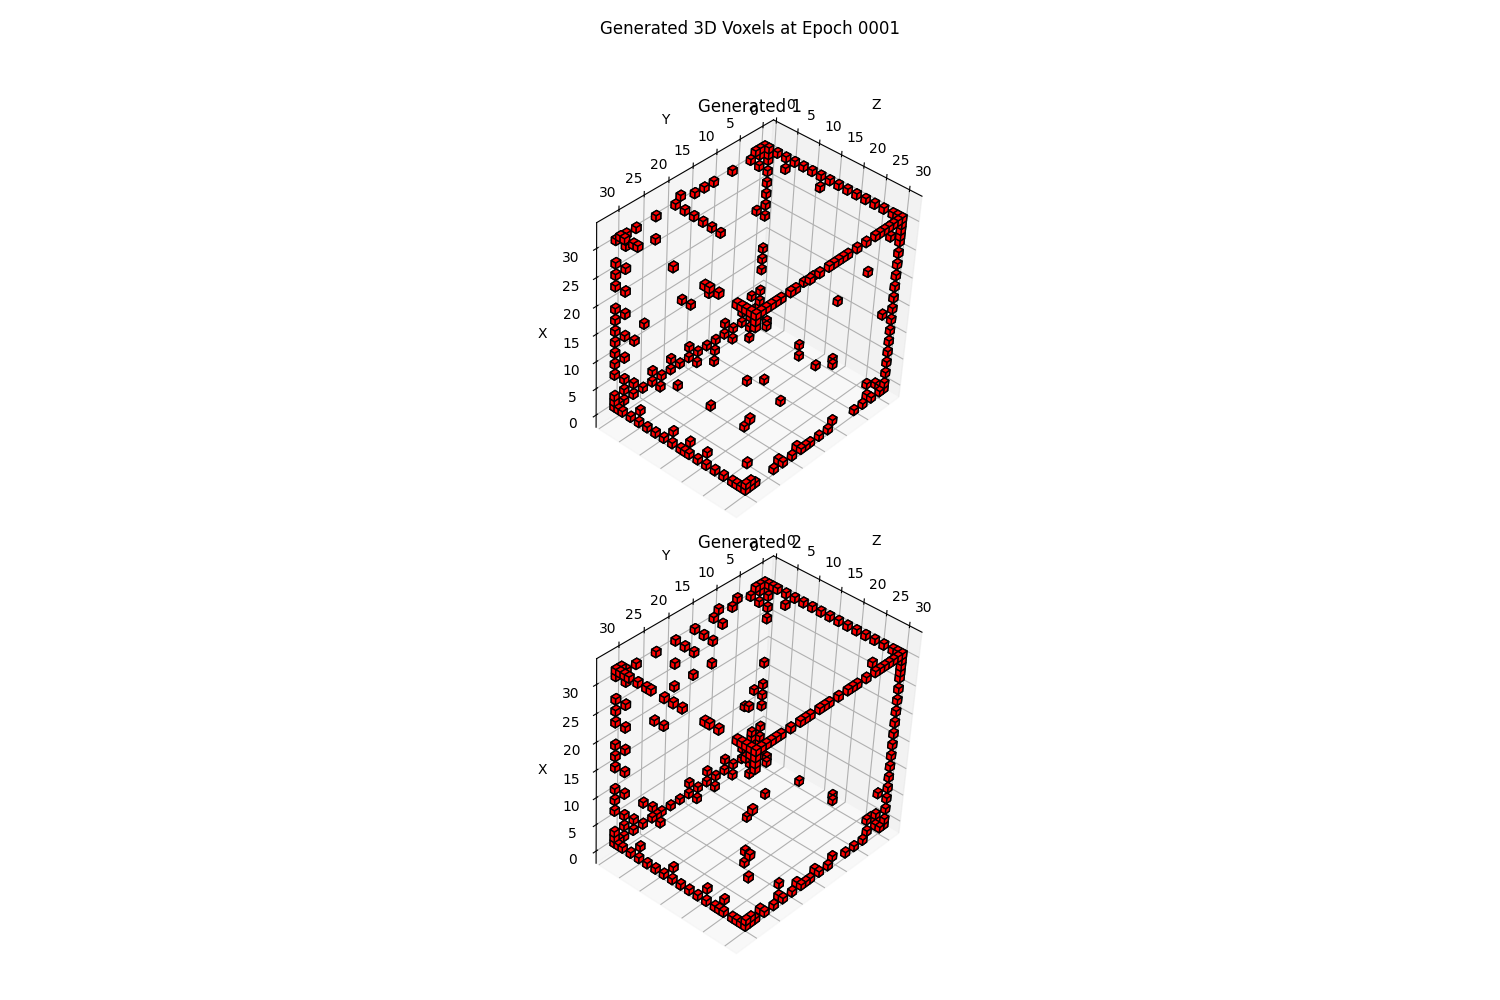

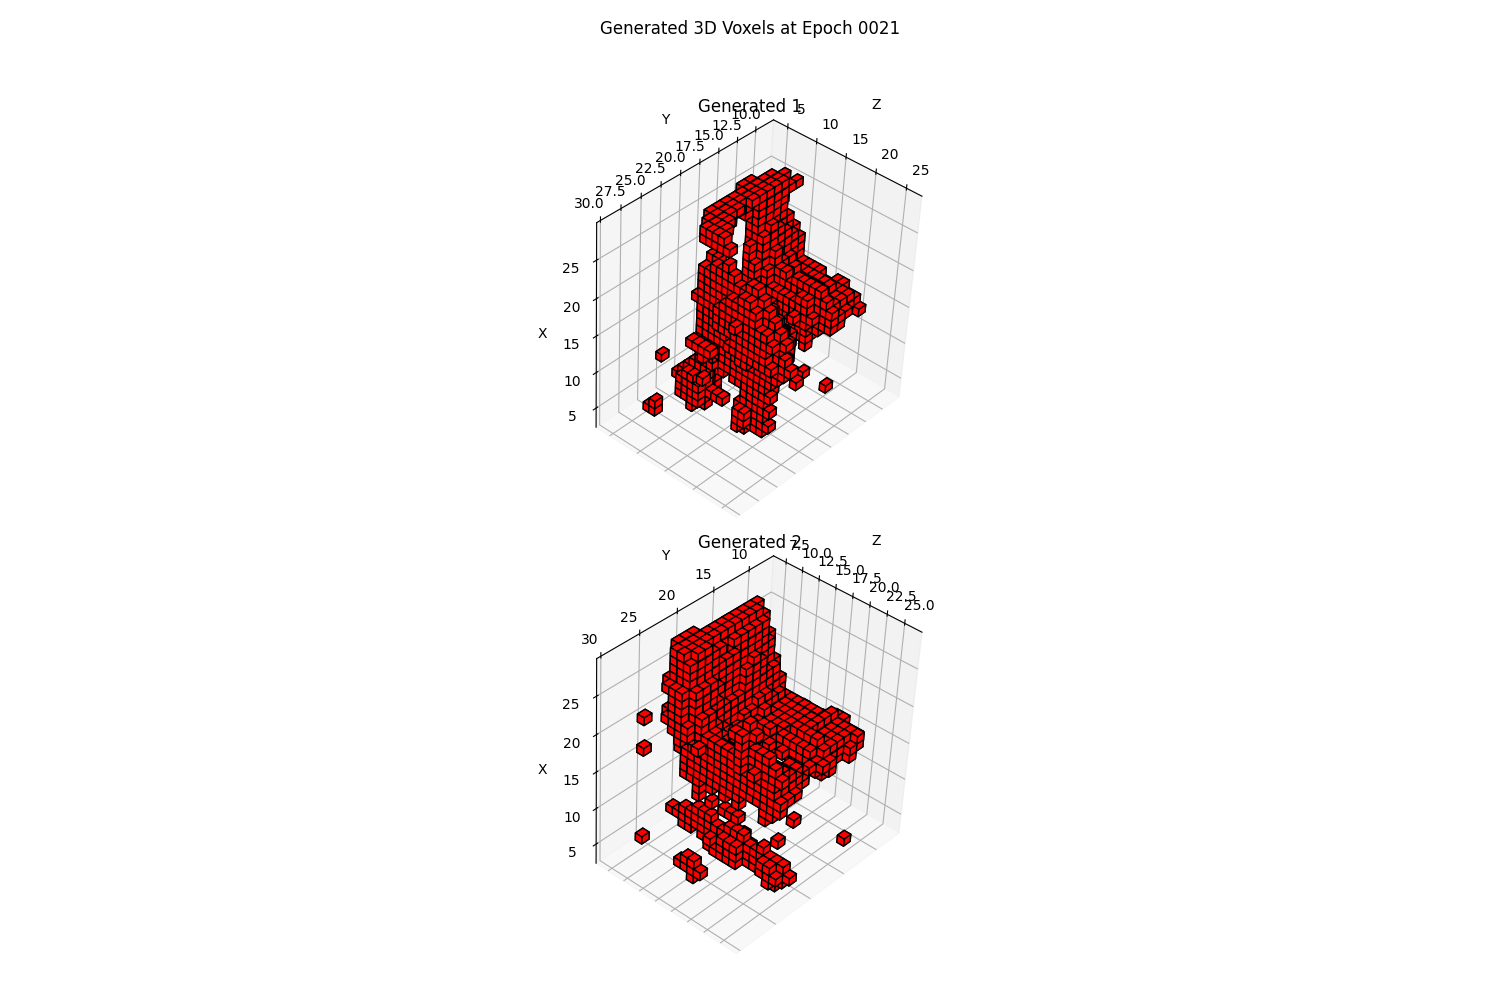

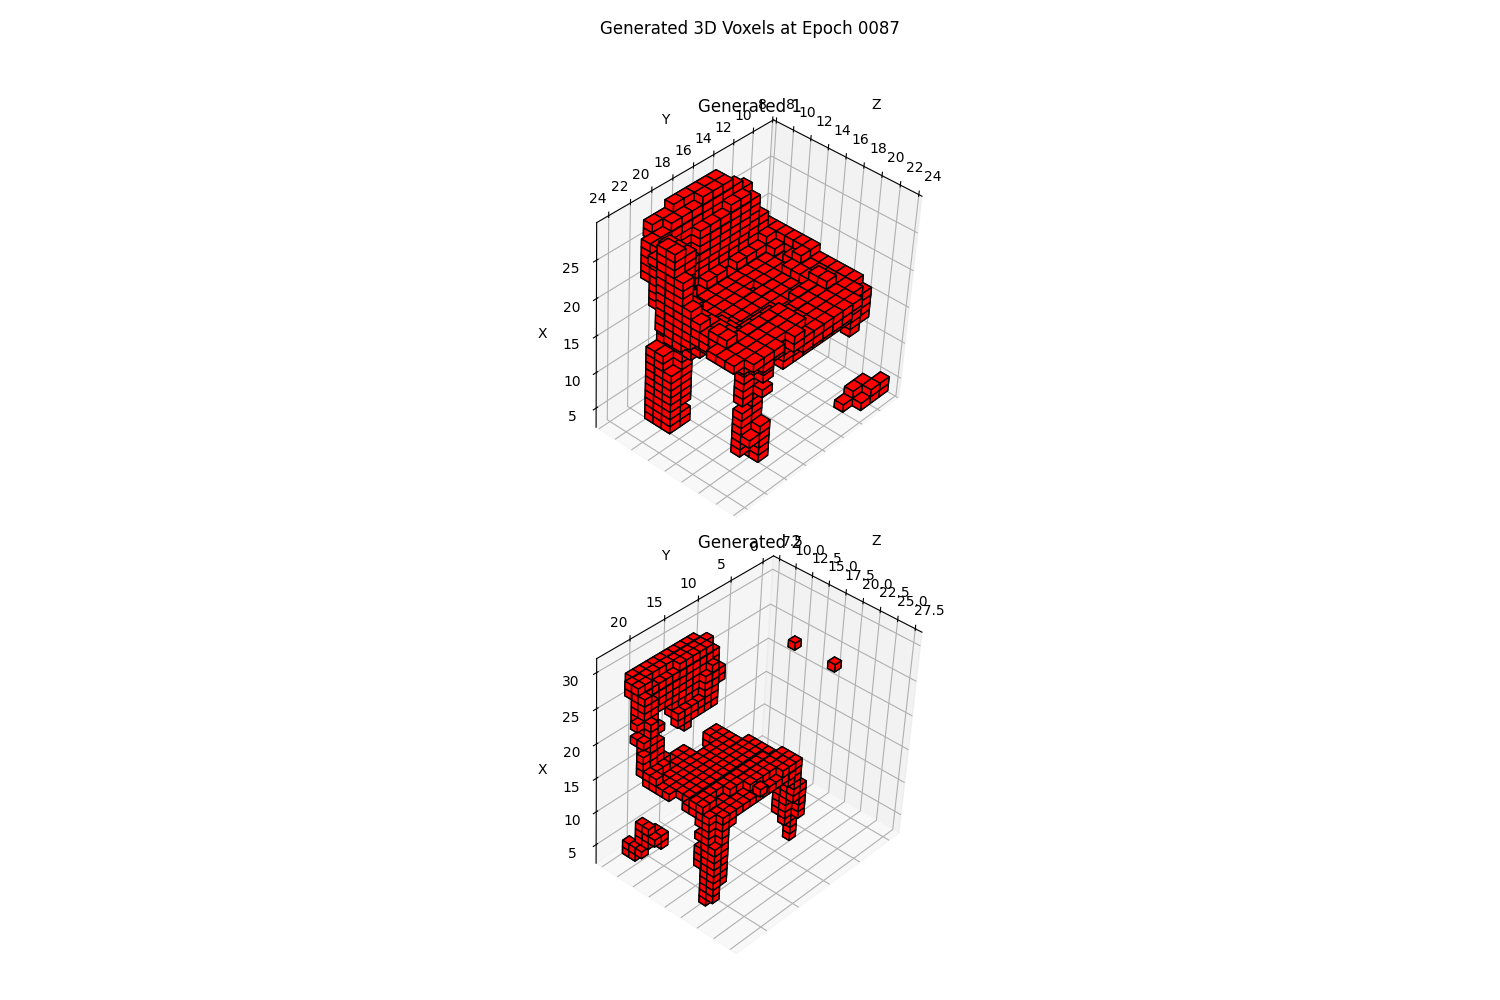

##3D-GAN from paper

Now we will try to implement the model proposed in "Learning a Probabilistic Latent Space of Object
Shapes via 3D Generative-Adversarial Modeling" by Jiajun Wu, Chengkai Zhang, Tianfan Xue, William T. Freeman, Joshua B. Tenenbaum

###Generator

This generator starts with a linear projection of the noise vector, reshapes it into a 5D tensor, and uses four ConvTranspose3d layers with ReLU activations and batch norm to upsample from a small spatial dimension (e.g., 2³) to the target size (e.g., 32³), halving channels at each step and it allows configurable output activation (Sigmoid or Tanh). The generator used previously first processes the noise with a linear layer followed by BatchNorm1d and LeakyReLU(0.2), reshapes to a fixed 4³ volume, then upsamples via three ConvTranspose3d layers (with LeakyReLU) before a final detail-refining Conv3d layer. Both output 32³ volumes but differ in upsampling steps, activation choices, and initial projection.

In [ ]:
class Generator(torch.nn.Module):
    def __init__(self, in_channels=512, out_dim=32, out_channels=1, noise_dim=200, activation="sigmoid"):
        super(Generator, self).__init__()
        self.in_channels = in_channels
        self.out_dim = out_dim
        self.in_dim = int(out_dim / 16)
        conv1_out_channels = int(self.in_channels / 2.0)
        conv2_out_channels = int(conv1_out_channels / 2)
        conv3_out_channels = int(conv2_out_channels / 2)

        self.linear = torch.nn.Linear(noise_dim, in_channels * self.in_dim * self.in_dim * self.in_dim)

        self.conv1 = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=in_channels, out_channels=conv1_out_channels, kernel_size=(4, 4, 4),
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(conv1_out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=conv1_out_channels, out_channels=conv2_out_channels, kernel_size=(4, 4, 4),
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(conv2_out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=conv2_out_channels, out_channels=conv3_out_channels, kernel_size=(4, 4, 4),
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(conv3_out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=conv3_out_channels, out_channels=out_channels, kernel_size=(4, 4, 4),
                stride=2, padding=1, bias=False
            )
        )
        if activation == "sigmoid":
            self.out = torch.nn.Sigmoid()
        else:
            self.out = torch.nn.Tanh()

    def project(self, x):
        """
        projects and reshapes latent vector to starting volume
        :param x: latent vector
        :return: starting volume
        """
        return x.view(-1, self.in_channels, self.in_dim, self.in_dim, self.in_dim)

    def forward(self, x):
        x = self.linear(x)
        x = self.project(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return self.out(x)


Steps same as before

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        #nn.init.xavier_uniform_(m.weight.data)
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        #nn.init.xavier_uniform_(m.weight.data)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.2)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
BATCH_SIZE = 32
LATENT_SPACE_DIMENSION = 200
generator = Generator(LATENT_SPACE_DIMENSION)
generator.apply(weights_init)

Generator(
  (linear): Linear(in_features=200, out_features=1600, bias=True)
  (conv1): Sequential(
    (0): ConvTranspose3d(200, 100, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): ConvTranspose3d(100, 50, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): ConvTranspose3d(50, 25, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv4): Sequential(
    (0): ConvTranspose3d(25, 1, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
  )
  (out): Sigmoid()
)

###Discriminator

The discriminator consists of 5 volumetric convolution
layers, with numbers of channels {32, 128, 256, 512, 1}, kernel sizes {4, 4, 4, 4, 4}, and strides
{2, 2, 2, 2, 1}. There are leaky ReLU layers of parameter 0.2 and batch normalization layers in between, and a Sigmoid layer at the end.
When it comes to the differences whe have that first discriminator is simpler, dropout-regularized, and outputs logits while this one uses batch norm, sigmoid outputs, and a modular design allowing more configurability. One of the most noticable differences is how the two differ when it comes to regularization and normalization, in fact while in the first I chose to add dropout to weaken its discriminating capabilities, in this one the paper proposes the use of batchnorm without any kind of dropout.




In [ ]:
class Discriminator(torch.nn.Module):
    def __init__(self, in_channels=1, dim=32, out_conv_channels=512):
        super(Discriminator, self).__init__()
        conv1_channels = int(out_conv_channels / 8)
        conv2_channels = int(out_conv_channels / 4)
        conv3_channels = int(out_conv_channels / 2)
        self.out_conv_channels = out_conv_channels
        self.out_dim = int(dim / 16)

        self.conv1 = nn.Sequential(
            nn.Conv3d(
                in_channels=in_channels, out_channels=conv1_channels, kernel_size=4,
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(conv1_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(
                in_channels=conv1_channels, out_channels=conv2_channels, kernel_size=4,
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(conv2_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv3d(
                in_channels=conv2_channels, out_channels=conv3_channels, kernel_size=4,
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(conv3_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv3d(
                in_channels=conv3_channels, out_channels=out_conv_channels, kernel_size=4,
                stride=2, padding=1, bias=False
            ),
            nn.BatchNorm3d(out_conv_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.out = nn.Sequential(
            nn.Linear(out_conv_channels * self.out_dim * self.out_dim * self.out_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        # Flatten and apply linear + sigmoid
        x = x.view(-1, self.out_conv_channels * self.out_dim * self.out_dim * self.out_dim)
        x = self.out(x)
        return x

In [ ]:
discriminator = Discriminator()
discriminator.apply(weights_init)

Discriminator(
  (conv1): Sequential(
    (0): Conv3d(1, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv2): Sequential(
    (0): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv3): Sequential(
    (0): Conv3d(128, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv4): Sequential(
    (0): Conv3d(256, 512, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, t

###Helper functions

In [ ]:
import torch
from torch.autograd.variable import Variable
import torch.nn as nn


def ones_target(size, device):
    '''
    Tensor containing ones, with shape = size
    '''
    data = Variable(torch.ones(size, 1, device=device))
    return data


def zeros_target(size, device):
    '''
    FAKE data
    Tensor containing zeros, with shape = size
    '''
    data = Variable(torch.zeros(size, 1, device=device))
    return data


def train_discriminator(discriminator, optimizer, real_data, fake_data, loss_fn):
    cuda = next(discriminator.parameters()).is_cuda
    N_real = real_data.size(0) # Get actual batch size of real data
    N_fake = fake_data.size(0) # Get actual batch size of fake data
    # Reset gradients
    optimizer.zero_grad()
    # Train on Real Data
    prediction_real = discriminator(real_data)
    # Calculate error and backpropagate
    target_real = ones_target(N_real, real_data.device) # Use actual batch size for target
    error_real = loss_fn(prediction_real, target_real)
    error_real.backward()

    # Train on Fake Data
    prediction_fake = discriminator(fake_data)
    # Calculate error and backpropagate
    target_fake = zeros_target(N_fake, fake_data.device) # Use actual batch size for target
    error_fake = loss_fn(prediction_fake, target_fake)
    error_fake.backward()

    # Update weights with gradients
    optimizer.step()

    # Return error and predictions for real and fake inputs
    return error_real + error_fake, prediction_real, prediction_fake


def train_generator(discriminator, optimizer, fake_data, loss_fn):
    cuda = next(discriminator.parameters()).is_cuda
    N = fake_data.size(0)  # Get actual batch size of fake data
    # Reset gradients
    optimizer.zero_grad()  # Sample noise and generate fake data
    prediction = discriminator(fake_data)  # Calculate error and backpropagate
    target = ones_target(N, fake_data.device) # Use actual batch size for target

    error = loss_fn(prediction, target)
    error.backward()  # Update weights with gradients
    optimizer.step()  # Return error
    return error

###Training

Copied the "genarate_and_save_images" from before to change the number of examples to display if needed for the next training loops

In [ ]:
def generate_and_save_images(model, epoch, test_input):
    model.eval()
    with torch.no_grad():
        predictions = model(test_input).detach().cpu()

    # Visualize the generated 3D voxels
    fig = plt.figure(figsize=(15, 10))

    # Display a few generated examples
    num_examples_to_display = 2

    for i in range(num_examples_to_display):
        ax = fig.add_subplot(2, num_examples_to_display//2, i+1, projection='3d')

        # Get a single generated voxel grid
        generated_voxel_grid = predictions[i, 0].numpy()

        thresholded_voxel_grid = (generated_voxel_grid > 0.5)

        ax.voxels(thresholded_voxel_grid, facecolor='red', edgecolor='k')

        ax.set_title(f"Generated {i+1}",pad=40)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=30, azim=45, roll=240)

    plt.suptitle(f"Generated 3D Voxels at Epoch {epoch:04d}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('generated_voxels_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

    model.train()


In this block of code we don't rely on the function "training_step" and we decide to do everything in a single function.
Optimizers have been tuned according to the paper's instructions with a much higher generator learning rate with respect to the discriminator. Originally the discriminator was supposed to have a learning rate of 10^-5 but after a first trial I found that in this particular case it worked better with 10^-4 as value.
In this training function I followed a very important step mentioned in the paper which was to train the discriminator only if its accuracy was below 0.8, reason being that since discriminating is a much simpler job than generating some sort of balance of performance must be added on top of a less performing optimizer.

In [ ]:
def train_gan(generator,discriminator,dataloader,noise_dim=200,num_epochs=100,device=None,dis_train_threshold=0.8):
    generator.to(device)
    discriminator.to(device)

    # Loss and optimizers
    loss = nn.BCELoss()
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0025, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
    gloss = []
    dloss = []
    # Training loop
    for epoch in range(num_epochs):
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        d_losses_epoch = []
        g_losses_epoch = []
        d_real_preds_epoch = []
        d_fake_preds_epoch = []

        for real_images, _,_ in progress_bar:
            # Move real data to device
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # Generate a small batch of fake images to evaluate D's current performance
            with torch.no_grad():
                noise_eval = torch.randn(batch_size, noise_dim, device=device)
                fake_images_eval = generator(noise_eval)
                pred_real_eval = discriminator(real_images)
                pred_fake_eval = discriminator(fake_images_eval)

                # Simple accuracy calculation (number of correctly classified samples / total samples)
                # Threshold predictions at 0.5
                correct_real = (pred_real_eval >= 0.5).float().mean().item()
                correct_fake = (pred_fake_eval < 0.5).float().mean().item()
                current_d_accuracy = (correct_real + correct_fake) / 2.0


            d_loss = torch.tensor(0.0).to(device) # Initialize loss to 0 if not trained
            d_real = torch.tensor(0.0).to(device)
            d_fake = torch.tensor(0.0).to(device)

            #Train discriminator only if its accuracy is below 0.8
            if current_d_accuracy < dis_train_threshold:
                # Generate fake data for training
                noise_d = torch.randn(batch_size, noise_dim, device=device)
                fake_images_d = generator(noise_d).detach()

                # Train discriminator
                d_loss, d_real, d_fake = train_discriminator(discriminator, optimizer_D, real_images, fake_images_d, loss)
                d_losses_epoch.append(d_loss.item())
                d_real_preds_epoch.append(torch.mean(d_real).item())
                d_fake_preds_epoch.append(torch.mean(d_fake).item())


            noise_g = torch.randn(batch_size, noise_dim, device=device)
            fake_images_g = generator(noise_g)

            # Train generator
            g_loss = train_generator(discriminator, optimizer_G, fake_images_g, loss)
            g_losses_epoch.append(g_loss.item())

            #Log the progress
            progress_bar.set_postfix(
                D_loss=d_loss.item(), # This will be 0 if D was not trained
                G_loss=g_loss.item(),
                D_real=torch.mean(pred_real_eval).item(), # Use evaluation predictions for logging
                D_fake=torch.mean(pred_fake_eval).item(), # Use evaluation predictions for logging
                D_Acc=current_d_accuracy
            )
        gloss.append(np.mean(g_losses_epoch))
        dloss.append(np.mean(d_losses_epoch))

        generate_and_save_images(generator, epoch + 1, seed.to(device))

        plt.figure(figsize=(10, 5))
        plt.plot(gloss, label='Generator Loss')
        plt.plot(dloss, label='Discriminator Loss')
        plt.title('Generator and Discriminator Loss during Training')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
        print(f"Generator loss: {gloss[-1]}")
        print(f"Discriminator loss: {dloss[-1]}")

    print("Training complete!")


In [ ]:
train_gan(generator,discriminator,chair_train_dataloader,noise_dim=200,num_epochs=100,device="cuda")

##3D-GAN from paper using entire MN10 dataset (single orientation)

Since the second architecture looks like the better performing one, let's try to see if feeding the entire MN10 dataset produces satisfactory results or it leaves us with very noisy results or succumbs to mode collapse

In [ ]:
TGT_POSE = [6,18,42,66,90,114,138,162,186,198] #Rotations labels picked so that all objects have the same orientation

def create_no_rotations_dataset(original_dataset):
    norot_data = []
    norot_data_labels = []
    norot_data_label_poses = []

    # Iterate through the original dataset
    for i in range(len(original_dataset)):
        data, label, label_pose = original_dataset[i]
        if label_pose in TGT_POSE:
            norot_data.append(data)
            norot_data_labels.append(label)
            norot_data_label_poses.append(label_pose)

    # Convert lists to numpy arrays
    norot_data = np.array(norot_data)
    norot_data_labels = np.array(norot_data_labels)
    norot_data_label_poses = np.array(norot_data_label_poses)

    # Let's create a simplified class for the filtered dataset
    class FilteredVoxelDataset(torch.utils.data.Dataset):
        def __init__(self, data, labels, label_poses, transforms=None):
            self.data = data
            self.labels = labels
            self.label_poses = label_poses
            self.transforms = transforms

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            data = self.data[idx]
            label = self.labels[idx]
            label_pose = self.label_poses[idx]

            if self.transforms:
                data = self.transforms(data)

            return data, label, label_pose

    norot_data_dataset = FilteredVoxelDataset(norot_data, norot_data_labels, norot_data_label_poses, transforms=transforms)

    return norot_data_dataset

norot_data_train_dataset = create_no_rotations_dataset(combined_dataset)

norot_data_dataloader = DataLoader(norot_data_train_dataset, 32, shuffle=True, num_workers=0)

print(f"Number of samples in the training dataset: {len(norot_data_train_dataset)}")


Number of samples in the training dataset: 4899


Same steps as before

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        #nn.init.xavier_uniform_(m.weight.data)
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        #nn.init.xavier_uniform_(m.weight.data)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.2)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
BATCH_SIZE = 32
LATENT_SPACE_DIMENSION = 200
num_examples_to_generate = 6
seed = torch.randn([num_examples_to_generate, noise_dim])
generator = Generator(LATENT_SPACE_DIMENSION)
generator.apply(weights_init)

Generator(
  (linear): Linear(in_features=200, out_features=1600, bias=True)
  (conv1): Sequential(
    (0): ConvTranspose3d(200, 100, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): ConvTranspose3d(100, 50, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): ConvTranspose3d(50, 25, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv4): Sequential(
    (0): ConvTranspose3d(25, 1, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
  )
  (out): Sigmoid()
)

In [ ]:
discriminator = Discriminator()
discriminator.apply(weights_init)

Discriminator(
  (conv1): Sequential(
    (0): Conv3d(1, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv2): Sequential(
    (0): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv3): Sequential(
    (0): Conv3d(128, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv4): Sequential(
    (0): Conv3d(256, 512, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, t

In [ ]:
train_gan(generator,discriminator,norot_data_dataloader,noise_dim=200,num_epochs=100,device="cuda")